In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [7]:
categorical_cols = df.select_dtypes(include=["string"]).columns
numarical_cols = df.select_dtypes(include=["number"]).columns

In [8]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')

In [9]:
numarical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')

In [10]:
# no use in ml

# df = df.drop("Applicant_ID" , axis = 1)

In [11]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [12]:
from sklearn.impute import SimpleImputer

In [13]:
# # fillingmissing values

num_imp = SimpleImputer(strategy="mean")
df[numarical_cols] = num_imp.fit_transform(df[numarical_cols])

In [14]:
df[numarical_cols].isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Age                   0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
dtype: int64

In [15]:
cate_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cate_imp.fit_transform(df[categorical_cols])

In [16]:
df[categorical_cols].isnull().sum()

Employment_Status    0
Marital_Status       0
Loan_Purpose         0
Property_Area        0
Education_Level      0
Gender               0
Employer_Category    0
Loan_Approved        0
dtype: int64

<!-- EDA -->

EDA

In [17]:
df["Loan_Approved"]

0       No
1       No
2      Yes
3       No
4      Yes
      ... 
995     No
996     No
997     No
998    Yes
999     No
Name: Loan_Approved, Length: 1000, dtype: str

Text(0.5, 1.0, 'Is loan approved or not?')

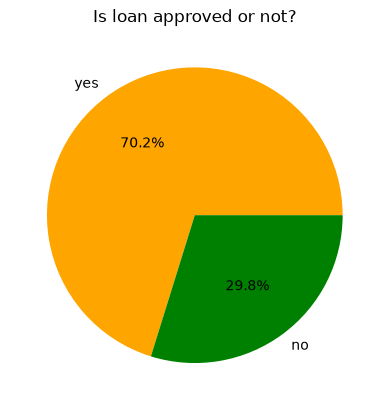

In [18]:
count = df["Loan_Approved"].value_counts()
color = ("orange" , "green")
plt.pie(count, labels = ["yes" , "no"] ,colors = color, autopct = "%1.1f%%")
plt.title("Is loan approved or not?")

[Text(0, 0, '621'), Text(0, 0, '379')]

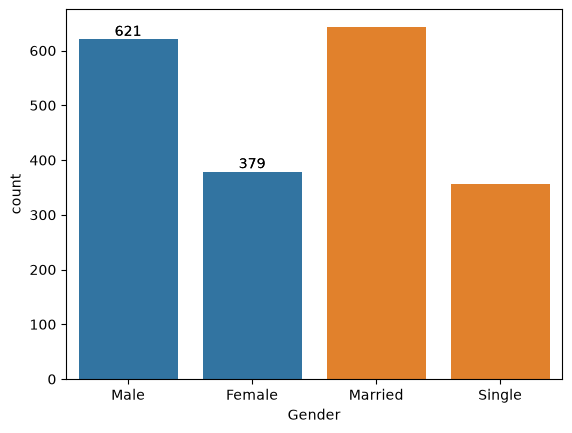

In [19]:
# analyze categories

gender_count = df["Gender"].value_counts()
a = sns.barplot(gender_count)

a.bar_label(a.containers[0])


mari_count = df["Marital_Status"].value_counts()
b = sns.barplot(mari_count)

b.bar_label(b.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

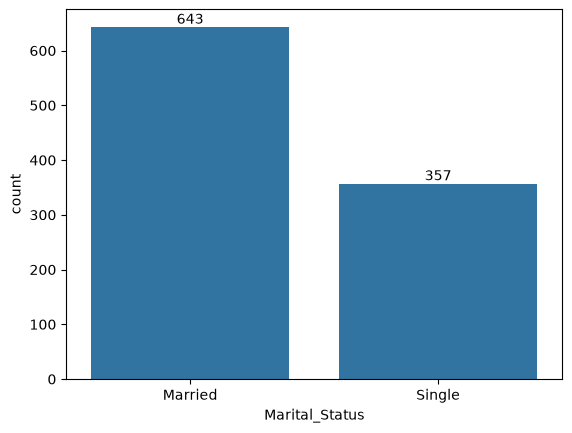

In [20]:
mari_count = df["Marital_Status"].value_counts()
b = sns.barplot(mari_count)

b.bar_label(b.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

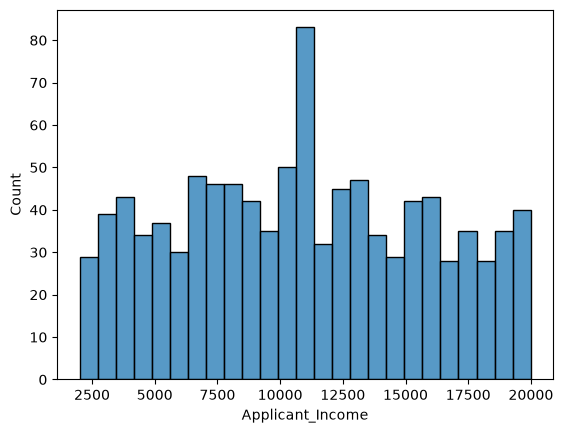

In [21]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
     bins = 25
)

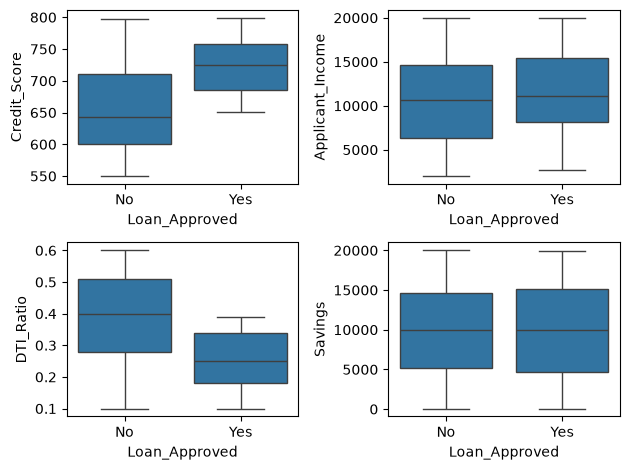

In [22]:
fig, axes = plt.subplots(2,2)


sns.boxplot(
    ax = axes[0,0],
    data = df,
    x = "Loan_Approved",
    y = "Credit_Score"
)
sns.boxplot(
    ax = axes[0,1],
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)
sns.boxplot(
    ax = axes[1,0],
    data = df,
    x = "Loan_Approved",
    y = "DTI_Ratio"
)
sns.boxplot(ax = axes[1,1],data = df,x = "Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

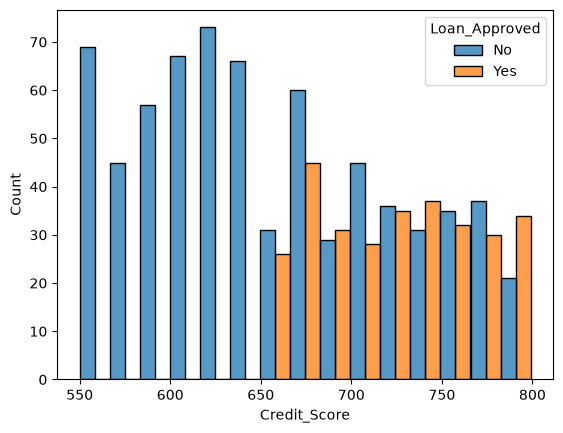

In [23]:
# when the loan get apporved

sns.histplot(
    data = df,
    x = "Credit_Score", 
    hue = "Loan_Approved",
    bins = 15,
    multiple = "dodge"
)

ENCODER---->

In [24]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

In [25]:
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   str    
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   str    
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   str    
 15  Property_Area       1000 non-null   str    
 16  Education_Level   

In [26]:
# for lebel encoding  (0 , 1)

le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [27]:
# for onehot encoding

cols = ["Employment_Status" , "Marital_Status" , "Gender" , "Employer_Category", "Property_Area" , "Loan_Purpose"]


ohe = OneHotEncoder(drop = "first" , sparse_output = False , handle_unknown = "ignore") 

encoded = ohe.fit_transform(df[cols])

encoded = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(cols) , index = df.index)

df = pd.concat([df.drop(columns=cols) , encoded] , axis = 1)

In [28]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
0,1.0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2.0,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,3.0,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
996,997.0,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
997,998.0,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
998,999.0,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level                 

In [30]:
df = df.drop("Applicant_ID" , axis = 1)

In [31]:
num_cols = df.select_dtypes(include = "number")
corr_matrix = num_cols.corr()

In [32]:
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,-0.025011,0.102589,-0.044639,-0.011995,0.004845,-0.036260,-0.083398,0.032794,0.074209,-0.031234
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,-0.001146,0.037640,0.004312,-0.047929,-0.010058,0.030045,-0.020148,0.028000,0.016022,0.059549
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.066041,0.021232,-0.012960,0.072462,0.003100,-0.025661,-0.025521,-0.006283,0.029865,0.037293
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.009250,-0.018757,0.030197,-0.054147,-0.032278,0.024082,-0.043685,-0.044642,0.027343,-0.005785
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,-0.007076,0.066736,-0.000049,-0.046087,-0.006946,0.004445,-0.030142,0.026013,-0.008658,0.015324
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.009642,0.030520,-0.019306,0.045391,-0.053971,0.035629,-0.025228,-0.010035,0.001777,0.023212
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,-0.007214,0.002090,-0.003506,0.026018,0.044898,-0.006156,-0.020907,0.040432,-0.014125,-0.036648
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,-0.011683,0.004381,-0.030208,0.027178,0.005438,0.016833,-0.009133,0.032558,-0.012217,-0.028948
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.035760,-0.013464,-0.014480,-0.009655,0.020061,0.007975,0.031112,0.040406,-0.050975,-0.007120
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,0.013108,-0.025975,0.013923,-0.026566,0.040206,-0.050076,-0.006788,-0.006119,-0.000930,0.032498


<Axes: >

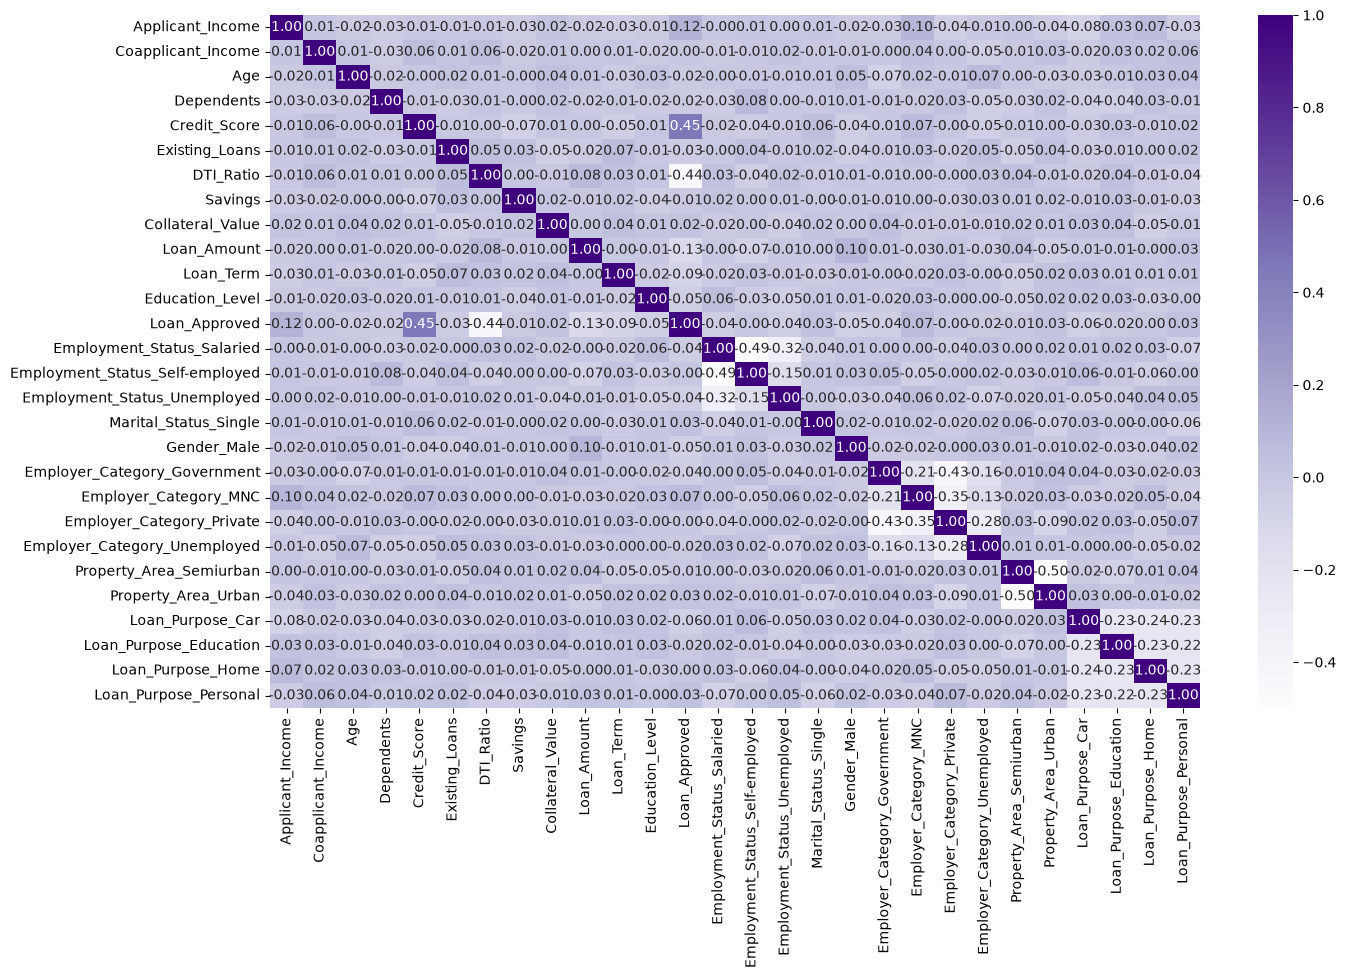

In [33]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

# jitna bada number utne jada chances loan millne ke
plt.figure(figsize = (15,9))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "Purples", 
    fmt = ".2f"
)


Train-Test-split + Feature scaling

In [34]:
x = df.drop("Loan_Approved" , axis=1)

y= df["Loan_Approved"]

In [35]:
x.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [36]:
x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size = 0.2 , random_state = 42
)

In [37]:
x_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [40]:
x_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.80384461e-01, -4.88252079e-01, -4.64548675e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.80384461e-01,  2.04812236e+00, -4.64548675e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.80384461e-01, -4.88252079e-01,  2.15262696e+00],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
         2.08166600e+00, -4.88252079e-01, -4.64548675e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.80384461e-01,  2.04812236e+00, -4.64548675e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
        -4.80384461e-01, -4.88252079e-01, -4.64548675e-01]],
      shape=(800, 27))

TRAIN AND EVLAUTE MODELS

In [41]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , f1_score

In [42]:
# LogisticRegression
log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)

y_pred = log_model.predict(x_test_scaled)

print("--Logistic Regression Model--")
print("precision : ", precision_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("accuracy_score : ", accuracy_score(y_test , y_pred))
print("recall_score : ", recall_score(y_test , y_pred))
print("f1_score : ", f1_score(y_test , y_pred))

--Logistic Regression Model--
precision :  0.7833333333333333
confusion_matrix :  [[126  13]
 [ 14  47]]
accuracy_score :  0.865
recall_score :  0.7704918032786885
f1_score :  0.7768595041322314


In [43]:
# knn

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 9)

knn_model.fit(x_train_scaled , y_train)

y_pred = knn_model.predict(x_test_scaled)

print("KNN Model")

print("precision: ", precision_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("accuracy_score : ", accuracy_score(y_test , y_pred))
print("recall_score : ", recall_score(y_test , y_pred))
print("f1_score : ", f1_score(y_test , y_pred))

KNN Model
precision:  0.6585365853658537
confusion_matrix :  [[125  14]
 [ 34  27]]
accuracy_score :  0.76
recall_score :  0.4426229508196721
f1_score :  0.5294117647058824


In [44]:
# naive bayse
from sklearn.naive_bayes import GaussianNB



log_model = GaussianNB()
log_model.fit(x_train_scaled, y_train)

y_pred = log_model.predict(x_test_scaled)

print("--naive_bayes Model--  -Best-")
print("precision : ", precision_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("accuracy_score : ", accuracy_score(y_test , y_pred))
print("recall_score : ", recall_score(y_test , y_pred))
print("f1_score : ", f1_score(y_test , y_pred))

--naive_bayes Model--  -Best-
precision :  0.8035714285714286
confusion_matrix :  [[128  11]
 [ 16  45]]
accuracy_score :  0.865
recall_score :  0.7377049180327869
f1_score :  0.7692307692307693


Feature Engineering

In [45]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

x = df.drop(columns = ["Loan_Approved" , "Credit_Score" , "DTI_Ratio"])
y = df["Loan_Approved"]

x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size = 0.2 , random_state = 42
)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [46]:
x_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Employer_Category_Private,Employer_Category_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0324,457021.542187


In [47]:
# LogisticRegression
log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)

y_pred = log_model.predict(x_test_scaled)

print("--Logistic Regression Model--")
print("precision : ", precision_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("accuracy_score : ", accuracy_score(y_test , y_pred))
print("recall_score : ", recall_score(y_test , y_pred))
print("f1_score : ", f1_score(y_test , y_pred))

--Logistic Regression Model--
precision :  0.7903225806451613
confusion_matrix :  [[126  13]
 [ 12  49]]
accuracy_score :  0.875
recall_score :  0.8032786885245902
f1_score :  0.7967479674796748


In [48]:
# knn

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 9)

knn_model.fit(x_train_scaled , y_train)

y_pred = knn_model.predict(x_test_scaled)

print("KNN Model")

print("precision: ", precision_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("accuracy_score : ", accuracy_score(y_test , y_pred))
print("recall_score : ", recall_score(y_test , y_pred))
print("f1_score : ", f1_score(y_test , y_pred))

KNN Model
precision:  0.6666666666666666
confusion_matrix :  [[124  15]
 [ 31  30]]
accuracy_score :  0.77
recall_score :  0.4918032786885246
f1_score :  0.5660377358490566


In [49]:
# naive bayse
from sklearn.naive_bayes import GaussianNB



log_model = GaussianNB()
log_model.fit(x_train_scaled, y_train)

y_pred = log_model.predict(x_test_scaled)

print("--naive_bayes Model--  -Best-")
print("precision : ", precision_score(y_test , y_pred))
print("confusion_matrix : ", confusion_matrix(y_test , y_pred))
print("accuracy_score : ", accuracy_score(y_test , y_pred))
print("recall_score : ", recall_score(y_test , y_pred))
print("f1_score : ", f1_score(y_test , y_pred))

--naive_bayes Model--  -Best-
precision :  0.7833333333333333
confusion_matrix :  [[126  13]
 [ 14  47]]
accuracy_score :  0.865
recall_score :  0.7704918032786885
f1_score :  0.7768595041322314
